# Quality Evaluation of RUC17 Post-Editing Sessions

## Sentence BLEU × COMET-QE × Syntactic Complexity

### What You Will Do In This Lesson

1. **Setup, load, and prepare data**: install/import libraries, load the RUC17 tables (SG, ST, TT) from the TPR-DB (en → zh), and build segment-aligned parallel texts with `prep_parallel_texts` — merged segments are split automatically
2. Compute **multi-reference sentence BLEU** for every **post-edited (P)** segment, using the from-scratch human translations (T sessions) of the same source segment as the reference pool
3. Build the **(source, target) pairs** for COMET
4. Compute **reference-free COMET (quality estimation)** scores for every (source, post-edited target) segment pair
5. Correlate BLEU and COMET (Pearson & Spearman)
6. Compute **dependency-based syntactic complexity** (IDT, DLT, IDT+DLT, NND, LE, BCR) and correlate it with both quality metrics

**Scope.** This lesson evaluates the **post-editing (P) sessions only**. The from-scratch translation (T) sessions are still loaded and used — but exclusively as the **reference pool** for BLEU; they are never themselves scored or analyzed.

### ⚠️ Before you start

- In Colab, switch to a **GPU runtime** for the COMET step (`Runtime → Change runtime type → T4 GPU`). CPU works too, just slower.
- The COMET step **defaults to a non-gated model** (`Unbabel/wmt20-comet-qe-da`) that runs with zero setup. For final, publication-grade numbers you can switch to the stronger gated `Unbabel/wmt22-cometkiwi-da` — Step 4 explains the one-time Hugging Face setup.

## Step 1: Setup, Load, and Prepare Data

This single step installs the libraries, imports them, loads all three RUC17 table types into DataFrames, and prepares the segment-aligned parallel texts that every later step works on.

### Libraries

- **NumPy**, **Pandas**, **SciPy `stats`**, **Matplotlib**, **Seaborn**: the usual scientific stack
- **NLTK**: provides `sentence_bleu` and smoothing functions
- **tprdb-utilities**: used for getting data remotely from the CRITT TPR-DB and reading data tables into a Pandas DataFrame
- **spaCy**: only its `displacy` visualizer is used, to draw dependency trees from the pre-parsed tables (no language model is downloaded)
- **unbabel-comet**: the COMET quality-estimation library (large install; it is installed **here, together with everything else**, so that pip resolves one mutually consistent set of versions — installing it later would downgrade NumPy underneath already-loaded packages and break the session)

### ⚠️ Colab notes

1. After the install cell finishes the **first** time, do `Runtime → Restart session`, then re-run from the top. On the second pass the check will report everything installed and you can continue straight through.
2. pip may print scary-looking dependency-conflict warnings about `opencv`, `tensorflow`, `jax`, `cudf`, etc. — those are other pre-installed Colab packages complaining. **This notebook does not use them; the warnings are harmless here.**

In [1]:
# Environment Setup
import sys
from importlib.metadata import version, PackageNotFoundError
from packaging.version import Version

# Enforce a minimum Python version of 3.9+
if sys.version_info < (3, 9):
    raise RuntimeError(
        f"❌ Python 3.9 or higher is required. "
        f"You are currently running Python {sys.version_info.major}.{sys.version_info.minor}."
    )

REQUIRED = {
    "numpy": "1.26.0",
    "pandas": "2.2.0",
    "scipy": "1.11.0",
    "matplotlib": "3.7.0",
    "seaborn": "0.13.0",
    "nltk": "3.8.0",
    "tprdb-utilities": "0.4.0",
    "unbabel-comet": "2.2.0",
    "spacy": "3.7.0",
}

def _check_versions():
    outdated = []
    for pkg, min_ver in REQUIRED.items():
        try:
            installed = version(pkg)
            if Version(installed) < Version(min_ver):
                outdated.append(f"  {pkg}: installed {installed}, need >={min_ver}")
        except PackageNotFoundError:
            raise ImportError(f"{pkg} is not installed")
    return outdated

# Check if dependencies are missing and install them automatically
try:
    import numpy as np
    import pandas as pd
    import scipy.stats
    import matplotlib.pyplot as plt
    import seaborn as sns
    import nltk
    import tprdb_utilities

    outdated = _check_versions()
    if outdated:
        raise ImportError("Outdated packages:\n" + "\n".join(outdated))
    else:
        print("🤠 All core dependencies are already installed. You are ready to go! 🤘")
except ImportError:
    print("Missing dependencies detected. Installing required packages...")

    try:
        # The %pip magic ensures installation happens in the active Jupyter kernel
        # NOTE: everything (incl. unbabel-comet) is installed in ONE pip call so the
        # resolver picks a mutually consistent set of versions. Installing comet
        # separately later would downgrade numpy underneath already-loaded packages.
        %pip install -q "numpy>=1.26.0" "pandas>=2.2.0" "scipy>=1.11.0" "matplotlib>=3.7.0" "seaborn>=0.13.0" "nltk>=3.8.0" "tprdb-utilities>=0.4.0" "unbabel-comet>=2.2.0" "spacy>=3.7.0"

        print("\n🤠 Installation complete 🤘")
        print("⚠️ On Google Colab: now do Runtime → Restart session, then re-run the notebook from the top.")
        print("   (Colab pre-loads numpy/pandas, so a restart is needed for the freshly installed versions to load.)")
        print("   You may see pip warnings about opencv/tensorflow/jax version conflicts — these are")
        print("   harmless here: this notebook does not use those packages.")
    except Exception as e:
        print(f"❌ An error occurred during installation: {e}")
        print("If using Google Colab, you may just have to restart your runtime now to use the newly installed packages.")

🤠 All core dependencies are already installed. You are ready to go! 🤘


In [2]:
# Now, import the libraries

try:
    # Standard Python library imports
    import re
    import numpy as np
    import pandas as pd
    import scipy.stats as stats
    import matplotlib
    import matplotlib.pyplot as plt
    import seaborn as sns
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

    # TPR-DB utilities import
    from tprdb_utilities import fetch_TPRDB_tables, read_TPRDB_tables, prep_parallel_texts

    print("✅ All imports successful!")

except ImportError as e:
    print(f"❌ An error occurred during imports: {e}")
    print("Please ensure all dependencies are installed and the kernel is restarted if necessary.")

✅ All imports successful!


### 🫵 Change code cell below

To get ready to run the `fetch_TPRDB_tables()` function, change the code cell below depending on your situation:
- **If *NOT* using Google Colab**:
    - Follow the **1st** set of directions to change the value of the `mothership_clone_location` variable
- **If you *are* using Google Colab**:
    - Follow the **2nd** set of directions to
        1. Comment out the code from the 1st set of directions
        2. Uncomment the code from the 2nd set of directions
        3. mount your Google Drive

In [3]:
# Commenting/Uncommenting Code: ⌘ + / (Mac) or Ctrl + / (Windows/Linux)

# 🫵 If NOT using Google Colab:
# 1) Change what's in the quotes below ("./") to point to where you want your mothership clone to be saved.
# 2) Then, run this code cell
mothership_clone_location = "./"

# 🫵 If using Google Colab:
# 1) Comment out the above line of code
# 2) Uncomment the lines of code below
# 3) Then, run this code cell

# from google.colab import drive
# drive.mount('/content/drive')
# mothership_clone_location = "/content/drive/MyDrive/"

We need three table types from RUC17:

- **SG tables** (`sg`): one row per target segment — this gives us the final Chinese target text (`String`), the segment alignment (`STseg`), and behavioral measures
- **ST tables** (`st`): one row per source token — we use these to reconstruct the English source text of every segment (needed for COMET-QE)
- **TT tables** (`tt`): one row per target token — their UD parses are used for target-side complexity and BCR in Step 6

In [4]:
# Fetch the RUC17 tables, read them into DataFrames, and inspect them
# (notice we are using the `mothership_clone_location` variable from the cell above)

fetch_TPRDB_tables(
    path=mothership_clone_location,
    studies=["RUC17"],
    extensions=["sg", "st", "tt"],
    public=True,
)

segments = read_TPRDB_tables(
    studies=["RUC17"],
    extension="sg",
    path=f"{mothership_clone_location}/tprdb-mothership-clone",
    user="PUBLIC",
    verbose=1,
)

stokens = read_TPRDB_tables(
    studies=["RUC17"],
    extension="st",
    path=f"{mothership_clone_location}/tprdb-mothership-clone",
    user="PUBLIC",
    verbose=1,
)

ttokens = read_TPRDB_tables(
    studies=["RUC17"],
    extension="tt",
    path=f"{mothership_clone_location}/tprdb-mothership-clone",
    user="PUBLIC",
    verbose=1,
)

# Check the DataFrames' shapes
print(f"📊 The segments (sg) table has {segments.shape[0]} rows and {segments.shape[1]} columns")
print(f"📊 The source-token (st) table has {stokens.shape[0]} rows and {stokens.shape[1]} columns")
print(f"📊 Sessions: {segments['Session'].nunique()}   Tasks: {dict(segments.groupby('Task')['Session'].nunique())}")

# Then, display the first few rows of the segments DataFrame with all columns visible
with pd.option_context("display.max_columns", None):
    display(segments.head())

  RUC17 [sg]: Done fetching (^_^)
  RUC17 [st]: Done fetching (^_^)
  RUC17 [tt]: Done fetching (^_^)

=== fetch_TPRDB_tables Summary ===
Clone dir: /content/tprdb-mothership-clone
User dir : PUBLIC

StudyID: RUC17
Extension  Status      Time
---------  ----------  ------
sg         Downloaded  0.44s
st         Downloaded  1.05s
tt         Downloaded  0.72s

To read these files into a DataFrame with read_TPRDB_tables:
  path      = "/content/tprdb-mothership-clone"
  user      = "PUBLIC"
  studies   = ['RUC17']
Reading: RUC17	with 124 'sg' Tables
Total 'sg' data rows: 838, columns: 39
Reading: RUC17	with 124 'st' Tables
Total 'st' data rows: 17509, columns: 91
Reading: RUC17	with 124 'tt' Tables
Total 'tt' data rows: 16735, columns: 75
📊 The segments (sg) table has 838 rows and 39 columns
📊 The source-token (st) table has 17509 rows and 91 columns
📊 Sessions: 124   Tasks: {'P': 62, 'T': 62}


,Id,Study,Session,StudySession,SL,TL,Task,Text,Part,KUI,PUB,STseg,TTseg,LenS,LenT,TokS,TokT,Ins,Del,Dur,FixS,TrtS,FixT,TrtT,Nedit,PreGap,PostGap,TB1000,TG1000,TD1000,TB_KUI,TG_KUI,TD_KUI,TB_PUB,TG_PUB,TD_PUB,String,HTot,HTotN
0,1,RUC17,P14_T6,RUC17@P14_T6,en,zh,T,6,P14,344,956,1,1,57,28,10,11,13,4,79860,42,17442,56,27839,0,132265,8297,11,75766,4094,16,79548,312,11,75766,4094,大多数_的_打猎_和_采集_社会_都_是_游牧_社会_。,1.4380,0.3385
1,2,RUC17,P14_T6,RUC17@P14_T6,en,zh,T,6,P14,344,956,2,2,123,49,22,20,20,2,31765,70,30783,41,10453,2,8656,5532,16,28749,3016,19,30952,813,16,28749,3016,以_这种_生存_方式_很_难_定居_下来_，_因为_一个_地区_的_资源_很_快_就_能_用完_，,1.6832,0.3962
2,3,RUC17,P14_T6,RUC17@P14_T6,en,zh,T,6,P14,344,956,3,3,117,42,20,17,19,6,33250,65,22034,53,21322,2,5532,15140,13,26532,6718,22,32703,547,14,27500,5750,也_因为_这个_原因_，_打猎_和_采集_社会_的_人口_密度_往往_都_很_低_。,1.8947,0.4460
3,4,RUC17,P14_T6,RUC17@P14_T6,en,zh,T,6,P14,344,956,4,4,153,33,22,13,18,5,49297,116,35404,38,13354,1,14781,1062,11,43971,5326,16,47845,1452,12,44955,4342,农业_社会_能_支持_的_人口_密度_为_60_到_100_倍_。,1.5653,0.3685
4,5,RUC17,P14_T6,RUC17@P14_T6,en,zh,T,6,P14,344,956,5,5,121,48,22,20,22,7,24688,73,24809,50,13285,1,1062,1219,13,17047,7641,23,23672,1016,13,17047,7641,打猎_和_采集_社会_的_社会_结构_往往_也_是_无_阶级_的_，_尽管_不_都_是_如此_。,1.7451,0.4108


### Prepare parallel texts (shared data preparation)

Every measure in this notebook operates on the same unit — one segment row:

| Measure | What it takes from the row |
|---------|---------------------------|
| BLEU (Step 2) | the target tokens as hypothesis |
| COMET-QE (Steps 3–4) | the (source, target) pair |
| Behavioral features | Dur, Ins, Del, Trt… of producing that target |
| TT complexity & BCR (Step 6) | the target's dependency parse |

Since `tprdb-utilities` **0.4.0**, the heavy lifting is done by **`prep_parallel_texts`** (see section *"3 — Transform data (transformer)"* in the [package documentation](https://pypi.org/project/tprdb-utilities/)). Given the SG, ST, and TT tables it:

1. **Splits merged segments** (`STseg` like `"1+2"`, where a participant fused two source sentences into one target segment) back into per-source-sentence units, using token-level alignment evidence with a sentence-punctuation fallback — the method developed for this notebook, now maintained upstream. Irreducible fusions are kept whole with their component source strings concatenated (they return with `STseg = <NA>`).
2. Returns **segment-aligned bitexts**: one DataFrame per participant with `String_ST` (the English source segment) and the participant's target segment, ready for MT evaluation.

The bitexts are *text-only*, so after calling the function we re-attach the study metadata this analysis needs: session ids, the merged-segment ids for the kept-whole rows, the SG behavioral measures — and for the rows created by splitting, the behavioral measures are **recomputed from the token tables** (their token slice inside the fused target is located by exact token-run match; `Nedit` is not reconstructable at token level and stays NaN for those rows).

In [5]:
# --- Prepare parallel texts: the package does the heavy lifting ---

bitexts = prep_parallel_texts(segments, stokens, ttokens, prep_tritexts=False)

# Assemble one long DataFrame (one row per participant-segment) with the
# columns needed for BLEU and COMET: this is ALL you need if your analysis
# uses only the quality metrics.
frames = []
for key, b in bitexts.items():
    part = key.split("_", 1)[1]
    d = b.rename(columns={f"String_{part}": "TgtString",
                          "String_ST": "SrcString"}).copy()
    d["Part"] = part
    frames.append(d)
para = pd.concat(frames, ignore_index=True)

# restore Session ids (bitexts carry Part/Task/Text, not Session)
lut = segments[["Part", "Task", "Text", "Session"]].drop_duplicates()
para = para.merge(lut, on=["Part", "Task", "Text"], how="left",
                  validate="many_to_one")

# kept-merged rows return with STseg <NA>: restore their merged id from SG
sg_merged = segments[segments["STseg"].astype(str).str.contains("+", regex=False)]
merged_of = dict(zip(sg_merged["Session"], sg_merged["STseg"].astype(str)))
para["Merged"] = para["STseg"].isna()
para["STseg"] = para.apply(
    lambda r: merged_of[r["Session"]] if pd.isna(r["STseg"])
    else str(int(r["STseg"])), axis=1)
# target tokens: keep the notebook's underscore convention
para["String"] = para["TgtString"].map(lambda s: "_".join(str(s).split()))

print(f"✅ {len(para)} aligned segment rows "
      f"({int((para['Task'] == 'P').sum())} P, "
      f"{int((para['Task'] == 'T').sum())} T), "
      f"{int(para['Merged'].sum())} kept-merged")

[P01] Resolving merged segments...
  Merged-segment rows: 0 split, 0 kept whole (flagged Merged=True)
[P02] Resolving merged segments...
  Merged-segment rows: 0 split, 0 kept whole (flagged Merged=True)
[P03] Resolving merged segments...
  Merged-segment rows: 0 split, 0 kept whole (flagged Merged=True)
[P04] Resolving merged segments...
  Merged-segment rows: 0 split, 0 kept whole (flagged Merged=True)
[P05] Resolving merged segments...
  Merged-segment rows: 0 split, 0 kept whole (flagged Merged=True)
[P08] Resolving merged segments...
  Merged-segment rows: 0 split, 0 kept whole (flagged Merged=True)
[P09] Resolving merged segments...
  Merged-segment rows: 0 split, 0 kept whole (flagged Merged=True)
[P10] Resolving merged segments...
  P10_T5 ST 1+2: split by alignment at token 11 (11/17 tokens)
  P10_P1 ST 4+5: split by alignment at token 14 (14/15 tokens)
  Merged-segment rows: 2 split, 0 kept whole (flagged Merged=True)
[P11] Resolving merged segments...
  Merged-segment rows: 

#### Re-attach study measures (needed for Step 6 and the exported CSV)

This notebook additionally exports SG behavioral measures (Dur, Ins, Del, Trt, …) and computes target-side complexity on dependency parses (Step 6), so we re-attach that metadata here: the SG measures merge back for every row that still exists in the SG table, and the rows *created by splitting* get their measures **recomputed from the token tables** (their token slice inside the fused target is located by exact token-run match; `Nedit` is not reconstructable at token level and stays NaN for those rows).

In [6]:
# --- Re-attach SG measures; recompute them for split rows ---

SG_MEASURES = ["LenS", "TokS", "TokT", "Ins", "Del", "Dur",
               "FixS", "TrtS", "FixT", "TrtT", "Nedit"]

sgk = segments.copy()
sgk["STseg"] = sgk["STseg"].astype(str)
para = para.merge(sgk[["Session", "STseg", "TTseg"] + SG_MEASURES],
                  on=["Session", "STseg"], how="left")

tt_by = dict(tuple(ttokens.groupby("Session")))
st_by = dict(tuple(stokens.groupby("Session")))
fused_ttseg = dict(zip(sg_merged["Session"], sg_merged["TTseg"]))
para["TTidFrom"] = np.nan
para["TTidTo"] = np.nan

split_idx = para.index[para["TTseg"].isna() & ~para["Merged"]]
for idx in split_idx:
    r = para.loc[idx]
    ttseg = fused_ttseg[r["Session"]]
    g = tt_by[r["Session"]]
    g = g[g["TTseg"].astype(str) == str(ttseg)].sort_values("TTid")
    toks = g["TToken"].astype(str).tolist()
    tgt = str(r["TgtString"]).split()
    sub = next((g.iloc[s0:s0 + len(tgt)]
                for s0 in range(len(toks) - len(tgt) + 1)
                if toks[s0:s0 + len(tgt)] == tgt), None)
    if sub is None:
        print(f"⚠️ could not locate token slice for {r['Session']} seg {r['STseg']}")
        continue
    st_seg = st_by[r["Session"]]
    st_seg = st_seg[st_seg["STseg"].astype(str) == r["STseg"]]
    para.loc[idx, ["TTseg", "TTidFrom", "TTidTo", "TokT", "TokS", "Nedit"]] = [
        ttseg, sub["TTid"].min(), sub["TTid"].max(), len(sub), len(st_seg), np.nan]
    para.loc[idx, "LenS"] = (int(st_seg["SToken"].astype(str).str.len().sum())
                             + max(len(st_seg) - 1, 0))
    for c in ("Ins", "Del", "Dur", "FixT", "TrtT"):
        para.loc[idx, c] = sub[c].sum()
    for c in ("FixS", "TrtS"):
        para.loc[idx, c] = st_seg[c].sum()

segments = para
print(f"✅ measures attached; {len(split_idx)} split rows recomputed from token slices")

✅ measures attached; 12 split rows recomputed from token slices


## Step 2: Compute multi-reference sentence BLEU

**Design.** RUC17 has no external gold reference, so each **post-edited segment** is scored against the **from-scratch human translations (T sessions)** of the same Text/STseg (≈8–11 independent references per segment). Because only P sessions are scored and only T sessions serve as references, hypothesis and reference sets never overlap, and every hypothesis gets the full reference pool.

Merged segments were split into per-segment units in Step 1, so almost every scored row is a clean one-source-sentence unit. Rows flagged `Merged=True` (irreducible fusions) remain concatenated units; they are kept in the data but can be excluded from unit-sensitive analyses with `df[~df["Merged"]]`. (Reference assembly handles both cases: per-segment references directly, and tiling for any kept-merged reference sessions.)

**Alternative reference pool (`REF_TASK = "P"`).** You can instead score each post-edited segment against the *other participants' post-edited* versions (the code automatically excludes the session's own output). ⚠️ Interpret this differently: all P sessions started from the **same MT output**, so PE outputs share the MT backbone — a PE-pool BLEU largely measures **conformity to the MT baseline / inter-post-editor consensus**, and can reward under-editing (barely-touched MT matches everyone else's barely-touched MT). It is a useful *secondary* measure of post-editing homogeneity, not a substitute for the T-pool quality score. Comparing the two per segment flags "post-editese": segments where post-editors converge on renderings human translators would not produce.

**Notes**
- The `String` column is already word-segmented Chinese (`_`-delimited), so tokenization is simply `split("_")`.
- A few sessions have **merged segments** (`STseg` like `"1+2"`); references are assembled by concatenating the corresponding reference segments.
- NLTK **smoothing method1** is applied — short segments otherwise produce hard zeros for 3/4-gram scores. Set `SMOOTHING = False` to reproduce unsmoothed scores.
- Interpretation: BLEU here measures **proximity to the pool of independent human translations**, not distance to a single gold answer.

In [7]:
# BLEU configuration

REF_TASK = "T"        # task whose sessions serve as references
SMOOTHING = True      # NLTK SmoothingFunction().method1

# The same seven weighting schemes as in the original BLEU notebook
WEIGHTS = {
    "1-gram": (1, 0, 0, 0),
    "2-gram": (0, 1, 0, 0),
    "3-gram": (0, 0, 1, 0),
    "4-gram": (0, 0, 0, 1),
    "cum-2": (0.5, 0.5, 0, 0),
    "cum-3": (1/3, 1/3, 1/3, 0),
    "cum-4": (0.25, 0.25, 0.25, 0.25),
}

# Behavioral measures carried over from the sg table for later analysis
BEHAVIORAL = ["LenS", "TokS", "TokT", "Ins", "Del", "Dur",
              "FixS", "TrtS", "FixT", "TrtT", "Nedit"]

In [8]:
# Helper functions

def seg_ids(stseg):
    """'4' -> (4,);  '1+2' -> (1, 2)  (merged segments)."""
    return tuple(int(x) for x in str(stseg).split("+"))


def tokens(string):
    """Chinese target string in sg is '_'-delimited word segmentation."""
    if pd.isna(string):
        return []
    return [t for t in str(string).split("_") if t]


def build_reference_pool(df, ref_task="T"):
    """pool[text][session][seg_ids] = token list of that segment."""
    pool = {}
    for _, row in df[df["Task"] == ref_task].iterrows():
        pool.setdefault(row["Text"], {}) \
            .setdefault(row["Session"], {})[seg_ids(row["STseg"])] = tokens(row["String"])
    return pool


def reference_for(pool_sess, want_ids):
    """Assemble the span `want_ids` from one reference session: exact
    match, or a concatenation of that session's spans tiling `want_ids`
    in order. Returns a token list or None."""
    if want_ids in pool_sess:
        return pool_sess[want_ids]
    remaining = list(want_ids)
    out = []
    while remaining:
        matched = False
        for ids, toks in pool_sess.items():
            if list(ids) == remaining[:len(ids)]:
                out.extend(toks)
                remaining = remaining[len(ids):]
                matched = True
                break
        if not matched:
            return None
    return out

In [9]:
# Compute sentence BLEU for every segment

pool = build_reference_pool(segments, ref_task=REF_TASK)
smooth = SmoothingFunction().method1 if SMOOTHING else None

# Hypotheses: POST-EDITING sessions only. T sessions are used solely as
# the reference pool (they are never scored). Merged rows were split into
# per-segment units above; the few irreducible ones carry Merged=True.
hypotheses = segments[segments["Task"] == "P"]

rows, skipped = [], 0
for _, row in hypotheses.iterrows():
    text, sess, ids = row["Text"], row["Session"], seg_ids(row["STseg"])
    hyp = tokens(row["String"])
    if not hyp:
        skipped += 1
        continue

    refs = []
    for ref_sess, segs in pool.get(text, {}).items():
        if ref_sess == sess:
            # self-exclusion: only relevant if REF_TASK == "P" (a session
            # must never serve as its own reference); a no-op for REF_TASK="T"
            continue
        r = reference_for(segs, ids)
        if r:
            refs.append(r)
    if not refs:
        print(f"no reference for {sess} text {text} seg {row['STseg']}")
        skipped += 1
        continue

    rec = {
        "Session": sess,
        "Part": row["Part"],
        "Task": row["Task"],
        "Text": text,
        "STseg": str(row["STseg"]),
        "TTseg": str(row["TTseg"]),
        "Merged": bool(row.get("Merged", False)),
        "TTidFrom": row.get("TTidFrom", np.nan),
        "TTidTo": row.get("TTidTo", np.nan),
        "NumRefs": len(refs),
    }
    for name, w in WEIGHTS.items():
        rec[name] = sentence_bleu(refs, hyp, weights=w, smoothing_function=smooth)
    for b in BEHAVIORAL:
        if b in row:
            rec[b] = row[b]
    rows.append(rec)

bleu_df = pd.DataFrame(rows)
print(f"✅ scored {len(bleu_df)} post-edited segments, skipped {skipped}")
print("\nMean sentence BLEU:")
display(bleu_df[list(WEIGHTS)].mean().round(4).to_frame("mean").T)

✅ scored 418 post-edited segments, skipped 0

Mean sentence BLEU:


,1-gram,2-gram,3-gram,4-gram,cum-2,cum-3,cum-4
mean,0.8664,0.6307,0.4261,0.269,0.7339,0.5994,0.4721


### Why do the n-gram levels differ so much?

The staircase you see above (1-gram ≫ 4-gram) is the universal signature of BLEU, and the gaps are informative. Each level asks a progressively harder question:

- **1-gram**: does each *word* of the hypothesis appear anywhere in the references? With ~10 references pooling their vocabulary, correct word choice is usually enough → high scores. Approximates **lexical adequacy**.
- **4-gram**: does each *four-word sequence* appear verbatim, in order, in a reference? Word choice, word order, and function-word placement must all align across a span — one reordered adverb breaks every n-gram spanning it (a single divergent word can kill four 4-grams at once). Approximates **phrasal similarity**.
- **cum-N** scores are geometric means of levels 1..N; **cum-4** is what papers conventionally call "BLEU".

If word matches were independent, 4-gram precision would be roughly (1-gram)⁴; observed 4-gram scores fall below that, because misses cluster around word-order and phrasing differences — exactly where different Chinese renderings of the same English sentence legitimately diverge. Reading for this dataset: post-editors used largely the same vocabulary as the human translators, but assembled it into noticeably different phrasing.

The cell below makes this concrete on one segment: every hypothesis n-gram is marked ✓ if it occurs in any reference. (Illustration only — real BLEU additionally clips repeated n-grams and applies the brevity penalty and smoothing.)

In [10]:
# --- Illustration: n-gram matching on one example segment ---

# pick the segment whose cum-4 score is closest to the median
ex = bleu_df.sort_values("cum-4").iloc[len(bleu_df) // 2]
row = hypotheses[(hypotheses["Session"] == ex["Session"])
                 & (hypotheses["STseg"].astype(str) == ex["STseg"])].iloc[0]
hyp = tokens(row["String"])
ids = seg_ids(row["STseg"])
refs = [r for _, segs in pool[row["Text"]].items()
        if (r := reference_for(segs, ids))]

print(f"Session {ex['Session']}, Text {ex['Text']}, segment {ex['STseg']}"
      f"  (cum-4 = {ex['cum-4']:.3f}, {len(refs)} references)")
print("HYP :", "".join(hyp))
print("REF1:", "".join(refs[0]))
print()

def ngrams(toks, n):
    return [tuple(toks[i:i + n]) for i in range(len(toks) - n + 1)]

for n in range(1, 5):
    ref_set = set()
    for r in refs:
        ref_set.update(ngrams(r, n))
    marks = [("✓" if g in ref_set else "✗", "·".join(g)) for g in ngrams(hyp, n)]
    hit = sum(m == "✓" for m, _ in marks)
    print(f"--- {n}-gram: {hit}/{len(marks)} in some reference "
          f"(precision ≈ {hit / len(marks):.2f})")
    print("   " + "  ".join(f"{m}{g}" for m, g in marks))
    print()

print("Note how ✗ marks cluster: one divergent word wipes out every "
      "higher-order n-gram that spans it.")

Session P22_P1, Text 1, segment 9  (cum-4 = 0.458, 11 references)
HYP : 警方了解到，杀人动机是因为诺里斯不喜欢和老人一起工作。
REF1: 警方获悉，诺瑞思杀人的动机是不喜欢同老年人一起工作。

--- 1-gram: 16/16 in some reference (precision ≈ 1.00)
   ✓警方  ✓了解  ✓到  ✓，  ✓杀人  ✓动机  ✓是  ✓因为  ✓诺里斯  ✓不  ✓喜欢  ✓和  ✓老人  ✓一起  ✓工作  ✓。

--- 2-gram: 10/15 in some reference (precision ≈ 0.67)
   ✓警方·了解  ✓了解·到  ✓到·，  ✗，·杀人  ✓杀人·动机  ✓动机·是  ✓是·因为  ✗因为·诺里斯  ✗诺里斯·不  ✓不·喜欢  ✓喜欢·和  ✗和·老人  ✗老人·一起  ✓一起·工作  ✓工作·。

--- 3-gram: 6/14 in some reference (precision ≈ 0.43)
   ✓警方·了解·到  ✓了解·到·，  ✗到·，·杀人  ✗，·杀人·动机  ✓杀人·动机·是  ✓动机·是·因为  ✗是·因为·诺里斯  ✗因为·诺里斯·不  ✗诺里斯·不·喜欢  ✓不·喜欢·和  ✗喜欢·和·老人  ✗和·老人·一起  ✗老人·一起·工作  ✓一起·工作·。

--- 4-gram: 2/13 in some reference (precision ≈ 0.15)
   ✓警方·了解·到·，  ✗了解·到·，·杀人  ✗到·，·杀人·动机  ✗，·杀人·动机·是  ✓杀人·动机·是·因为  ✗动机·是·因为·诺里斯  ✗是·因为·诺里斯·不  ✗因为·诺里斯·不·喜欢  ✗诺里斯·不·喜欢·和  ✗不·喜欢·和·老人  ✗喜欢·和·老人·一起  ✗和·老人·一起·工作  ✗老人·一起·工作·。

Note how ✗ marks cluster: one divergent word wipes out every higher-order n-gram that spans it.


## Step 3: Build the (source, target) pairs for COMET

COMET-QE needs the **source** of every segment — `prep_parallel_texts` already provides it (`String_ST`, our `SrcString` column), including the concatenated spans for the kept-merged rows, so no reconstruction is needed. Merged segments were split in Step 1, so (src, mt) pairs are one-to-one sentence pairs — the unit COMET is trained on — except the few irreducible `Merged=True` rows. The Chinese target is de-segmented for COMET (token boundaries removed; a space is kept only between adjacent Latin/alphanumeric tokens so embedded English does not fuse).

### ⚠️ What COMET scores here: the FINAL target text (TT), not raw MT

The COMET library requires its input fields to be named `src` and `mt` — that is just the **API's field naming convention**, not a statement about where the text comes from. In this notebook, the `mt` column always holds the **final target text (TT)** taken from the `String` column of the SG tables:

the `mt` field holds the participant's **post-edited final text** — the outcome of the post-editing session.

The **raw machine-translation output is never scored** — it is not even contained in the RUC17 Tables. Every COMET-QE score therefore answers: *given this English source segment, how good is this final post-edited Chinese segment?*

In [11]:
ASCII_END = re.compile(r"[A-Za-z0-9]$")
ASCII_START = re.compile(r"^[A-Za-z0-9]")

def detokenize_zh(string):
    toks = tokens(string)   # '发展中国家_不_愿…' -> plain Chinese for COMET
    out = ""
    for t in toks:
        if out and ASCII_END.search(out) and ASCII_START.search(t):
            out += " "
        out += t
    return out

pairs = []
# P sessions only — source and target come straight from prep_parallel_texts
for _, row in hypotheses.iterrows():
    pairs.append({
        "Session": row["Session"],
        "STseg": str(row["STseg"]),
        "src": row["SrcString"],
        # NOTE: "mt" is only the field name COMET's API expects.
        # The content is the FINAL target text (TT): the participant's
        # post-edited text. Raw MT output is never used (not in RUC17 Tables).
        "mt": detokenize_zh(row["String"]),
    })

pairs = pd.DataFrame(pairs)
print(f"✅ built {len(pairs)} (src, mt) pairs from post-editing sessions")
display(pairs.head(3))

✅ built 418 (src, mt) pairs from post-editing sessions


,Session,STseg,src,mt
0,P01_P4,1,Although developing countries are understandab...,发展中国家不愿为应对气候变化而牺牲其为穷人谋求更好生活水平的机会，尽管这可以理解，但是为应对...
1,P01_P4,2,Incentives must be offered to encourage develo...,必须提供奖励措施，鼓励发展中国家走出绿色发展之路，发展清洁技术，并且这也可以帮助减少因毁林而...
2,P01_P4,3,Some of the most vulnerable countries of the w...,世界上一些最脆弱的国家对气候变化的产生影响最小，但却同样遭受着气候变化带来的影响。


## Step 4: Compute reference-free COMET (QE) scores

Each **(source, final target)** pair is scored — see the note in Step 3: despite the `mt` field name, the model evaluates the participants' final TT, not raw machine translation.

### Which model?

| Model | Gated? | Quality | Use it when |
|-------|--------|---------|-------------|
| `Unbabel/wmt20-comet-qe-da` | ❌ no login needed | good (WMT20) | **default** — runs out of the box |
| `Unbabel/wmt22-cometkiwi-da` | ✅ HF login required | stronger (WMT22, standard in recent papers) | **final results for publication** |

The notebook **defaults to the non-gated WMT20 model** so the pipeline runs end-to-end with zero setup.

**📏 Score scales differ between the two models.** `wmt20-comet-qe-da` predicts **z-normalized** human judgment scores: the scale is unbounded, centered near the training data's average quality, and **negative scores are normal** — they mean "estimated below-average quality," not an error. `wmt22-cometkiwi-da` instead outputs a bounded ≈0–1 scale. Higher is better on both, and correlations are unaffected by the scale — but never interpret the absolute values as percentages, never compare scores across the two models, and always report which model produced your numbers. If you would like a more recent and reportedly "better" model, you could switch to **cometkiwi-22** (next cell).

⏱️ Scoring the ~420 post-edited segments takes about a minute on a T4 GPU, longer on CPU. (The `unbabel-comet` library itself was already installed in Step 1.)

In [12]:
# Default model: non-gated, no Hugging Face account needed
COMET_MODEL = "Unbabel/wmt20-comet-qe-da"

### 🫵 Optional upgrade: the gated `wmt22-cometkiwi-da` model

**What "gated" means:** some Hugging Face models are distributed under a license you must explicitly accept before the files can be downloaded. Until you (a) accept the license **and** (b) authenticate with a HF token, every download attempt fails with `401 Unauthorized` / `GatedRepoError` — which the comet library unhelpfully re-raises as `KeyError: "Model ... not supported by COMET."` If you see that error, it is **not** a bug in the notebook: it means one of the two steps below is missing.

**One-time setup (≈2 minutes):**

1. **Accept the license**: while logged in to your (free) Hugging Face account, open the model page [`Unbabel/wmt22-cometkiwi-da`](https://huggingface.co/Unbabel/wmt22-cometkiwi-da) and click **"Agree and access repository"**.
2. **Create a token**: HF → Settings → Access Tokens → *New token* with **Read** permission. Copy it.
3. **Give the token to Colab** — recommended: click the **🔑 key icon** in Colab's left sidebar → *Add new secret* → Name: `HF_TOKEN`, Value: your token → toggle **Notebook access on**. Then `Runtime → Restart session` and re-run from the top. The token is picked up automatically in all your notebooks from now on — no login cell needed.

Then uncomment the two lines in the cell below and run it.


In [ ]:
# 🫵 Uncomment the two lines below AFTER completing the one-time setup above
# to use the stronger gated model (recommended for the final paper numbers):

# COMET_MODEL = "Unbabel/wmt22-cometkiwi-da"
# print(f"Using gated model: {COMET_MODEL}")

# 🫵 Only needed if you did NOT store HF_TOKEN as a Colab secret:
# from huggingface_hub import notebook_login
# notebook_login()

**🛠️ Troubleshooting `ImportError: cannot import name 'runtime_version' from 'google.protobuf'`** in the next cell: this means transformers tried to import Colab's TensorFlow, which was broken by comet's protobuf downgrade. The `USE_TF=0` lines prevent that — but they only work if they run *before* transformers is first imported. If you already hit the error in this session, do `Runtime → Restart session` and re-run from the top so the import happens fresh.

In [13]:
# ⚠️ Keep these two lines BEFORE the comet import.
# The comet install downgrades protobuf, which breaks Colab's pre-installed
# TensorFlow. transformers (inside comet) would try to import that broken
# TensorFlow just because it exists — these env vars make it skip TF and
# use PyTorch only (which is all COMET needs).
import os
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"

import torch
from comet import download_model, load_from_checkpoint

print(f"Model: {COMET_MODEL}")
model_path = download_model(COMET_MODEL)
comet_model = load_from_checkpoint(model_path)

data = [{"src": r.src, "mt": r.mt} for r in pairs.itertuples()]
gpus = 1 if torch.cuda.is_available() else 0
print(f"scoring {len(data)} segments on {'GPU' if gpus else 'CPU'} ...")
out = comet_model.predict(data, batch_size=16, gpus=gpus)

pairs["COMET_QE"] = out.scores
print(f"✅ COMET-QE done ({COMET_MODEL}). System-level score: {out.system_score:.4f}")

Model: Unbabel/wmt20-comet-qe-da


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

LICENSE: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


scoring 418 segments on GPU ...


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Predicting DataLoader 0: 100%|██████████| 27/27 [00:06<00:00,  4.44it/s]


✅ COMET-QE done (Unbabel/wmt20-comet-qe-da). System-level score: 0.3783


In [14]:
# Merge BLEU and COMET into one segment-level DataFrame

df = bleu_df.merge(
    pairs[["Session", "STseg", "src", "mt", "COMET_QE"]],
    on=["Session", "STseg"], how="inner", validate="one_to_one")

print(f"📊 merged table: {df.shape[0]} rows × {df.shape[1]} columns")
df.to_csv("ruc17_bleu_comet.csv", index=False)
print("💾 saved ruc17_bleu_comet.csv")

print(f"\nMean COMET-QE: {df['COMET_QE'].mean():.4f}")

📊 merged table: 418 rows × 31 columns
💾 saved ruc17_bleu_comet.csv

Mean COMET-QE: 0.3783


### Average COMET score by group

The chart below shows which texts were post-edited more successfully (based on COMET-QE results), foreshadowing the complexity analysis in Step 6. Error bars are **95% confidence intervals** of the mean (±1.96 × SEM). Swap `GROUP_BY = "Text"` for `"Part"` to compare participants instead.

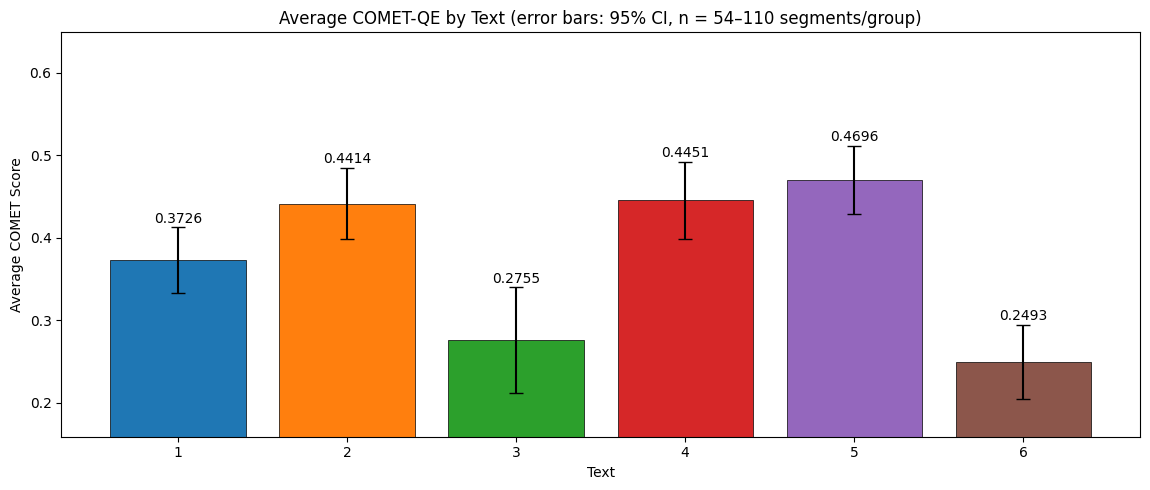

In [15]:
# --- Bar chart: mean COMET-QE per group, with 95% CI error bars ---

GROUP_BY = "Text"        # or "Part" for per-participant bars

g = df.groupby(GROUP_BY)["COMET_QE"].agg(["mean", "sem", "count"])
g["ci95"] = 1.96 * g["sem"]

fig, ax = plt.subplots(figsize=(1.6 * len(g) + 2, 5))
colors = plt.cm.tab10(range(len(g)))
bars = ax.bar([str(i) for i in g.index], g["mean"], yerr=g["ci95"],
              color=colors, capsize=5, edgecolor="black", linewidth=0.5)
for x, (m, ci) in enumerate(zip(g["mean"], g["ci95"])):
    ax.text(x, m + ci + 0.01 * (g["mean"].max() - g["mean"].min() + 1e-9),
            f"{m:.4f}", ha="center", va="bottom", fontsize=10)
ax.set_xlabel(GROUP_BY)
ax.set_ylabel("Average COMET Score")
ax.set_title(f"Average COMET-QE by {GROUP_BY} (error bars: 95% CI, "
             f"n = {int(g['count'].min())}–{int(g['count'].max())} segments/group)")
# zoom the y-axis to the data range, like published versions of this chart
lo = (g["mean"] - g["ci95"]).min(); hi = (g["mean"] + g["ci95"]).max()
pad = 0.15 * (hi - lo + 1e-9)
ax.set_ylim(lo - pad, hi + 3 * pad)
plt.tight_layout()
plt.show()

## Step 5: Correlate sentence BLEU and COMET-QE

We compute **Pearson r** and **Spearman ρ** between COMET-QE and every BLEU variant — overall and per task. Spearman is the headline number here: BLEU is bounded and skewed, so the relationship is unlikely to be linear.

In [16]:
BLEU_COLS = list(WEIGHTS)

def corr_table(d, y="COMET_QE"):
    rows = []
    for c in BLEU_COLS:
        sub = d[[c, y]].dropna()
        pr, pp = stats.pearsonr(sub[c], sub[y])
        sr, sp = stats.spearmanr(sub[c], sub[y])
        rows.append({"BLEU": c, "n": len(sub),
                     "Spearman_rho": round(sr, 3), "Spearman_p": fmt_p(sp),
                     "Pearson_r": round(pr, 3), "Pearson_p": fmt_p(pp)})
    return pd.DataFrame(rows).set_index("BLEU")

def fmt_p(p):
    # p-values: '<.001' below threshold, else 3 decimals (never a bare 0.0)
    return "<.001" if p < 0.001 else f"{p:.3f}"

display(corr_table(df))

,n,Spearman_rho,Spearman_p,Pearson_r,Pearson_p
BLEU,,,,,
1-gram,418,0.338,<.001,0.353,<.001
2-gram,418,0.272,<.001,0.305,<.001
3-gram,418,0.286,<.001,0.333,<.001
4-gram,418,0.271,<.001,0.324,<.001
cum-2,418,0.308,<.001,0.333,<.001
cum-3,418,0.307,<.001,0.343,<.001
cum-4,418,0.290,<.001,0.343,<.001


### Why is the correlation "only" ≈ 0.3?

A segment-level correlation of ρ ≈ 0.3 between BLEU and COMET-QE is a **normal** result, not a weak one, for four compounding reasons:

1. **Segment level is the hard setting.** Both metrics are noisy for a single sentence, and noise in *both* variables attenuates correlation multiplicatively (the observed value is capped by √(reliability₁ × reliability₂)). The same metrics that agree at r ≈ .8–.95 at the system level historically agree at only ≈ .2–.4 at the segment level.
2. **Different constructs by design.** BLEU rewards surface overlap with the reference pool (blind to meaning errors that preserve n-grams, harsh on legitimate paraphrase); COMET-QE judges meaning transfer from the source (blind to some fluency issues). If they agreed near-perfectly, one would be redundant — moderate agreement is the empirical case for reporting both.
3. **Restriction of range.** Post-edited output compresses quality into "mostly decent"; low variance mechanically shrinks correlations.
4. **The instruments.** wmt20-qe-da is the weaker QE model, and Chinese BLEU inherits word-segmentation noise.

Below, the left panel shows **cum-4** (the conventional "BLEU") and the right panel **1-gram**, which has the strongest association with COMET-QE in the table above — a substantive observation, not a coincidence: COMET-QE primarily judges *adequacy*, which lives in content-word choice (1-gram), while 4-gram overlap additionally requires matching one reference's exact phrasing, adding paraphrase noise.

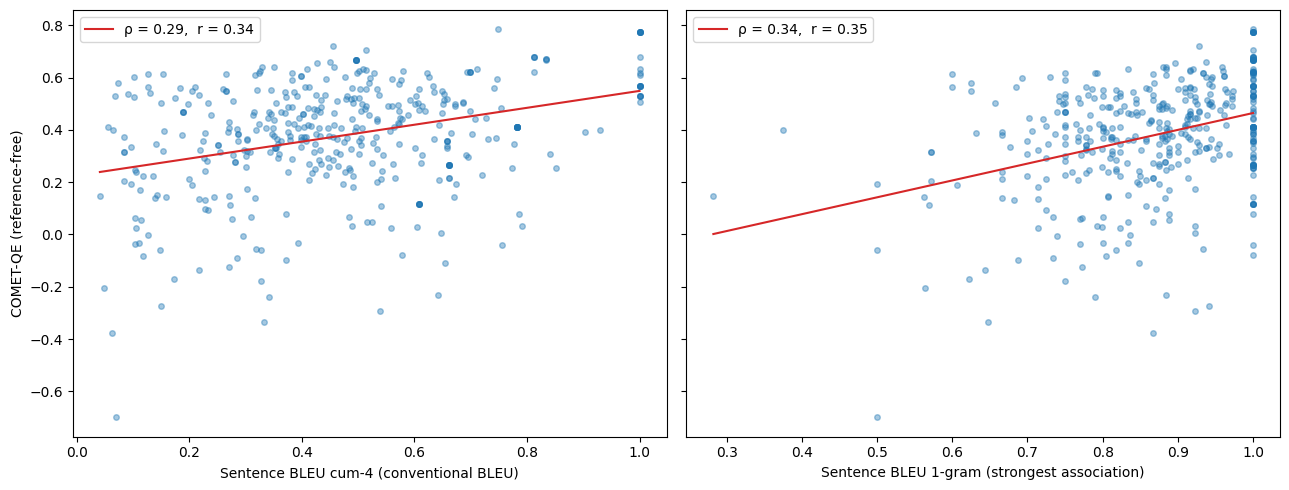

In [17]:
# Scatterplots: conventional BLEU (cum-4) and the strongest variant (1-gram)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, col, title in ((axes[0], "cum-4", "conventional BLEU"),
                       (axes[1], "1-gram", "strongest association")):
    ax.scatter(df[col], df["COMET_QE"], alpha=0.4, s=16, color="tab:blue")
    slope, icpt, r, _, _ = stats.linregress(df[col], df["COMET_QE"])
    rho, _ = stats.spearmanr(df[col], df["COMET_QE"])
    xs = pd.Series([df[col].min(), df[col].max()])
    ax.plot(xs, icpt + slope * xs, color="tab:red", lw=1.5,
            label=f"ρ = {rho:.2f},  r = {r:.2f}")
    ax.set_xlabel(f"Sentence BLEU {col} ({title})")
    ax.legend()
axes[0].set_ylabel("COMET-QE (reference-free)")
plt.tight_layout()
plt.show()

## Step 6: Dependency-based syntactic complexity (IDT, DLT, NND, LE, BCR)

We compute the metrics from the [**Syntactic Complexity Metrics for TPR-DB**](https://github.com/Critt-Kent/Syntactic-complexity) toolkit, using the **pre-parsed UD annotations** (`upos`, `head`, `deprel`) already in the ST and TT tables — no re-parsing needed:

| Metric | Level | What it measures |
|--------|-------|------------------|
| **IDT** | token | storage cost: dependencies spanning each token (Gibson 1998, 2000) |
| **DLT** | token | integration cost: discourse referents between a head and its farthest preceding dependent (Gibson 2000) |
| **IDT+DLT** | token | combined storage + integration cost |
| **NND** | segment | nested noun distance: linear distance between hierarchically related consecutive nouns (Zou 2024) |
| **LE** | segment | left-embeddedness: pre-verbal memory load (Zou 2024) |
| **BCR** | segment pair | bilingual complexity ratio: Metric_TT / Metric_ST (>1 = complication, <1 = simplification) |

Token-level metrics are aggregated per segment with **sum** (the toolkit's default, selected via correlation analysis). This implementation was **verified against the worked Example (1) in the toolkit README** — the object-extracted relative clause — reproducing the documented per-token IDT, DLT, IDT+DLT, NND, LE, and the sum/mean/max aggregation table exactly.

**Source-side metrics** (IDT_ST, …) are properties of the shared English source. **BCR** uses each session's own target parse from the TT tables, so it varies *per participant* — it captures how much syntactic transformation each post-editor applied.

**⚠️ A statistical note before correlating.** Source complexity is *shared*: every segment is post-edited by ~10 participants, so ST values repeat across rows. Correlating ST metrics on pooled rows pseudo-replicates (the real n is ~45 unique segments). ST metrics are therefore correlated at the **segment level** (quality averaged per Text/STseg). BCR varies per session, so it is correlated at the row level — though segments are still clustered, so treat p-values as exploratory (a mixed-effects model is the confirmatory tool).

In [18]:
# --- Syntactic complexity metrics (IDT, DLT, IDT+DLT, NND, LE) ---
# Implementation follows the "Syntactic Complexity Metrics for TPR-DB"
# README definitions; verified against its Example (1).

REFERENT_POS = {"NOUN", "PROPN", "VERB"}   # discourse referents (DLT)
NOUN_POS = {"NOUN", "PROPN"}               # nouns (NND)
AGGREGATION = "sum"                        # toolkit default


def token_complexity(upos, head):
    """Per-token IDT, DLT, IDT+DLT for one segment.
    upos: list of UPOS tags; head: local head positions (1-based, 0=root)."""
    n = len(upos)
    arcs = [(min(i + 1, h), max(i + 1, h))
            for i, h in enumerate(head) if h != 0]

    # IDT(t): arcs (a, b), a < b, spanning t with a <= t < b
    idt = [sum(1 for (a, b) in arcs if a <= t < b) for t in range(1, n + 1)]

    # DLT(h): discourse referents between h and its FARTHEST preceding
    # dependent d (including d, excluding h); non-heads get 0
    dlt = [0] * n
    for h in range(1, n + 1):
        preceding = [d + 1 for d, hh in enumerate(head)
                     if hh == h and d + 1 < h]
        if preceding:
            d = min(preceding)
            dlt[h - 1] = sum(1 for k in range(d, h)
                             if upos[k - 1] in REFERENT_POS)

    return idt, dlt, [a + b for a, b in zip(idt, dlt)]


def nnd_values(upos, head):
    """Per consecutive noun pair: |i-j| if one is a tree ancestor of the
    other, else 0."""
    nouns = [i + 1 for i, u in enumerate(upos) if u in NOUN_POS]

    def ancestors(t):
        seen = set()
        h = head[t - 1]
        while h != 0 and h not in seen:
            seen.add(h)
            h = head[h - 1]
        return seen

    return [abs(b - a) if (a in ancestors(b) or b in ancestors(a)) else 0
            for a, b in zip(nouns, nouns[1:])]


def le_values(upos):
    """Per verb: run of consecutive non-VERB, non-AUX tokens since the
    previous verb (or segment start)."""
    gaps, run = [], 0
    for u in upos:
        if u == "VERB":
            gaps.append(run)
            run = 0
        elif u != "AUX":
            run += 1
    return gaps


def aggregate(vals, how=AGGREGATION):
    if not vals:
        return 0.0
    return {"sum": sum, "mean": lambda v: sum(v) / len(v),
            "max": max}[how](vals)


def segment_complexity(g, tok_id_col, seg_col=None):
    """Compute segment metrics from one segment's token-table rows.
    Converts global token ids + head ids to local positions; rows with
    deprel == 'root' become head 0."""
    g = g.sort_values(tok_id_col)
    pos_of = {tid: i + 1 for i, tid in enumerate(g[tok_id_col])}
    upos = list(g["upos"])
    head = [0 if dep == "root" else pos_of.get(h, 0)
            for h, dep in zip(g["head"], g["deprel"])]
    idt, dlt, idtdlt = token_complexity(upos, head)
    return pd.Series({
        "IDT": aggregate(idt),
        "DLT": aggregate(dlt),
        "IDT_DLT": aggregate(idtdlt),
        "NND": aggregate(nnd_values(upos, head)),
        "LE": aggregate(le_values(upos)),
        "SegLen": sum(u != "PUNCT" for u in upos),
    })

METRICS = ["IDT", "DLT", "IDT_DLT", "NND", "LE"]
print("✅ complexity functions defined (aggregation:", AGGREGATION + ")")

✅ complexity functions defined (aggregation: sum)


In [19]:
# --- Source-side complexity: one value set per unique (Text, STseg) ---
# The source is identical across sessions, so parse one session per text.

first_sess = stokens.groupby("Text")["Session"].transform("first")
src_parse = stokens[stokens["Session"] == first_sess]
st_complexity = (src_parse.groupby(["Text", "STseg"])
                 .apply(segment_complexity, tok_id_col="STid",
                        include_groups=False)
                 .reset_index())
print(f"✅ ST complexity for {len(st_complexity)} unique source segments")
display(st_complexity.head())

# Attach to df (merged segments are excluded upstream, so each row maps
# to exactly one source segment; the tiling fallback below is kept for
# generality)
ST_COLS = [m + "_ST" for m in METRICS]

def st_for(text, stseg):
    ids = [int(x) for x in str(stseg).split("+")]
    rows = st_complexity[(st_complexity["Text"] == text)
                         & (st_complexity["STseg"].isin(ids))]
    if rows.empty:
        return pd.Series({c: np.nan for c in ST_COLS + ["SegLen_ST"]})
    out = {m + "_ST": rows[m].sum() for m in METRICS}
    out["SegLen_ST"] = rows["SegLen"].sum()
    return pd.Series(out)

df[ST_COLS + ["SegLen_ST"]] = df.apply(
    lambda r: st_for(r["Text"], r["STseg"]), axis=1)

✅ ST complexity for 41 unique source segments


,Text,STseg,IDT,DLT,IDT_DLT,NND,LE,SegLen
0,1,1,8.0,3.0,11.0,2.0,2.0,6.0
1,1,2,46.0,4.0,50.0,7.0,4.0,17.0
2,1,3,54.0,4.0,58.0,7.0,12.0,20.0
3,1,4,41.0,2.0,43.0,2.0,9.0,14.0
4,1,5,32.0,1.0,33.0,8.0,1.0,12.0


### Seeing the metrics: dependency tree of an example segment

The metrics above are all read off dependency arcs, so one picture makes them concrete. Below we draw the dependency tree of the **highest-NND source segment** in the dataset, straight from the pre-parsed `.st` table (displaCy in manual mode — no parsing, no model download), and print its metric values. Follow the arcs while re-reading the Step 6 definitions: IDT counts arcs *spanning* a token; NND is the distance between hierarchically related nouns; LE is the token run before the first verb.

Change `EX_TEXT` / `EX_SEG` to inspect any other segment — or uncomment the last lines to draw one participant's post-edited **target** tree from the `.tt` table (the TT side of BCR).

In [20]:
# --- Dependency-tree rendering from pre-parsed TPR-DB tables ---

from spacy import displacy

def dep_render(g, tok_col, id_col):
    """Draw the dependency tree of one segment's token-table rows."""
    g = g.sort_values(id_col)
    pos_of = {tid: i for i, tid in enumerate(g[id_col])}
    words = [{"text": str(t), "tag": str(u)}
             for t, u in zip(g[tok_col], g["upos"])]
    arcs = []
    for tid, h, dep in zip(g[id_col], g["head"], g["deprel"]):
        if dep == "root" or h not in pos_of:
            continue
        i, j = pos_of[tid], pos_of[h]
        arcs.append({"start": min(i, j), "end": max(i, j), "label": str(dep),
                     "dir": "left" if i < j else "right"})
    return displacy.render({"words": words, "arcs": arcs}, style="dep",
                           manual=True, jupyter=True,
                           options={"compact": True, "distance": 95})

# example: the highest-NND source segment (edit to explore)
ex = st_complexity.sort_values("NND", ascending=False).iloc[0]
EX_TEXT, EX_SEG = int(ex["Text"]), int(ex["STseg"])

g = src_parse[(src_parse["Text"] == EX_TEXT) & (src_parse["STseg"] == EX_SEG)]
print(f"Text {EX_TEXT}, segment {EX_SEG}: "
      + " ".join(g.sort_values("STid")["SToken"].astype(str)))
print("Metrics:", {m: round(float(ex[m]), 1) for m in METRICS})
dep_render(g, "SToken", "STid")

# 🫵 Uncomment to draw one participant's post-edited TARGET tree instead:
# sess = df[(df["Text"] == EX_TEXT) & (df["STseg"] == str(EX_SEG))]["Session"].iloc[0]
# ttseg = df[(df["Session"] == sess) & (df["STseg"] == str(EX_SEG))]["TTseg"].iloc[0]
# gt = ttokens[(ttokens["Session"] == sess) & (ttokens["TTseg"].astype(str) == ttseg)]
# dep_render(gt, "TToken", "TTid")

Text 3, segment 4: China , which has extensive investments in the Sudanese oil industry , maintains close links with the Government , which includes one minister charged with crimes against humanity by the International Criminal Court in The Hague .
Metrics: {'IDT': 119.0, 'DLT': 6.0, 'IDT_DLT': 125.0, 'NND': 26.0, 'LE': 20.0}


In [21]:
# --- Target-side complexity and BCR (per session: TT differs!) ---

# P sessions only (T sessions are reference material, not analysis targets)
tt_P = ttokens[ttokens["Task"] == "P"]
tt_complexity = (tt_P.groupby(["Session", "TTseg"])
                 .apply(segment_complexity, tok_id_col="TTid",
                        include_groups=False)
                 .reset_index())
tt_complexity["TTseg"] = tt_complexity["TTseg"].astype(str)
print(f"✅ TT complexity for {len(tt_complexity)} session-segments")

df["TTseg"] = df["TTseg"].astype(str)
df = df.merge(tt_complexity.rename(columns={m: m + "_TT" for m in METRICS})
              [["Session", "TTseg"] + [m + "_TT" for m in METRICS]],
              on=["Session", "TTseg"], how="left")

# Rows produced by splitting a merged segment: compute TT complexity on
# their own token slice (TTidFrom..TTidTo) instead of the whole fused TTseg,
# so the complexity unit matches the BLEU/COMET/behavioral unit.
# Note: dependency arcs crossing the slice boundary are treated as root
# attachments. When the split falls on a sentence boundary (the usual case)
# no arcs cross and the metrics are exact; for splits inside one fused
# syntactic sentence, IDT/DLT on the slices are slightly underestimated.
split_rows = df["TTidFrom"].notna()
for idx in df.index[split_rows]:
    r = df.loc[idx]
    sub = tt_P[(tt_P["Session"] == r["Session"])
               & (tt_P["TTid"] >= r["TTidFrom"])
               & (tt_P["TTid"] <= r["TTidTo"])]
    vals = segment_complexity(sub, tok_id_col="TTid")
    for m in METRICS:
        df.loc[idx, m + "_TT"] = vals[m]
print(f"   (TT complexity recomputed on token slices for {int(split_rows.sum())} split rows)")

# BCR = Metric_TT / Metric_ST (NaN where the ST metric is 0)
BCR_COLS = []
for m in METRICS:
    col = "BCR_" + m
    df[col] = df[m + "_TT"] / df[m + "_ST"].replace(0, np.nan)
    BCR_COLS.append(col)

df.to_csv("ruc17_bleu_comet_complexity.csv", index=False)
print("💾 saved ruc17_bleu_comet_complexity.csv")
print("\nMean BCR (>1 complication, <1 simplification):")
display(df[BCR_COLS].mean().round(3).to_frame("mean").T)

✅ TT complexity for 416 session-segments
   (TT complexity recomputed on token slices for 6 split rows)
💾 saved ruc17_bleu_comet_complexity.csv

Mean BCR (>1 complication, <1 simplification):


,BCR_IDT,BCR_DLT,BCR_IDT_DLT,BCR_NND,BCR_LE
mean,1.083,3.21,1.155,0.76,1.713


In [22]:
# --- Correlations, part 1: SOURCE complexity × quality (segment level) ---

seg_level = (df.groupby(["Text", "STseg"])
             .agg({"cum-4": "mean", "COMET_QE": "mean",
                   **{c: "first" for c in ST_COLS + ["SegLen_ST"]}})
             .reset_index())

rows = []
for c in ST_COLS + ["SegLen_ST"]:
    sub = seg_level[[c, "cum-4", "COMET_QE"]].dropna()
    rb, pb = stats.spearmanr(sub[c], sub["cum-4"])
    rc, pc = stats.spearmanr(sub[c], sub["COMET_QE"])
    rows.append({
        "Metric": c, "n": len(sub),
        "rho_BLEU": round(rb, 3), "p_BLEU": fmt_p(pb),
        "rho_COMET": round(rc, 3), "p_COMET": fmt_p(pc),
    })
print("=== ST complexity × mean post-editing quality (n = segments) ===")
display(pd.DataFrame(rows).set_index("Metric"))

=== ST complexity × mean post-editing quality (n = segments) ===


,n,rho_BLEU,p_BLEU,rho_COMET,p_COMET
Metric,,,,,
IDT_ST,42,-0.307,0.048,-0.079,0.619
DLT_ST,42,-0.176,0.264,-0.177,0.262
IDT_DLT_ST,42,-0.315,0.042,-0.079,0.620
NND_ST,42,-0.133,0.402,-0.225,0.151
LE_ST,42,-0.295,0.058,-0.110,0.488
SegLen_ST,42,-0.331,0.032,-0.081,0.608


In [23]:
# --- Correlations, part 2: BCR × quality (row level: BCR varies per session) ---

rows = []
for c in BCR_COLS:
    sub = df[[c, "cum-4", "COMET_QE"]].dropna()
    if len(sub) < 10:
        continue
    rb, pb = stats.spearmanr(sub[c], sub["cum-4"])
    rc, pc = stats.spearmanr(sub[c], sub["COMET_QE"])
    rows.append({
        "Metric": c, "n": len(sub),
        "rho_BLEU": round(rb, 3), "p_BLEU": fmt_p(pb),
        "rho_COMET": round(rc, 3), "p_COMET": fmt_p(pc),
    })
print("=== BCR × post-editing quality (row level, exploratory) ===")
display(pd.DataFrame(rows).set_index("Metric"))

=== BCR × post-editing quality (row level, exploratory) ===


,n,rho_BLEU,p_BLEU,rho_COMET,p_COMET
Metric,,,,,
BCR_IDT,417,-0.077,0.116,0.021,0.668
BCR_DLT,407,-0.256,<.001,-0.004,0.935
BCR_IDT_DLT,417,-0.123,0.012,0.027,0.588
BCR_NND,396,0.116,0.021,0.332,<.001
BCR_LE,390,-0.156,0.002,0.055,0.283


### Spearman correlation matrix for the complexity metrics

Before relating complexity to quality, it is worth seeing how the metrics relate to **each other**: a lower-triangle Spearman matrix over the five TT-side and five ST-side metrics.

Reading guide: with **sum** aggregation all metrics grow with segment length, which drives much of the shared variance; IDT+DLT correlates almost perfectly with IDT because DLT sums are small relative to IDT sums; and the TT↔ST blocks show how strongly target complexity tracks source complexity under post-editing. n = segment rows; note that ST values repeat across the ~10 participants per segment, so treat the stars as descriptive.

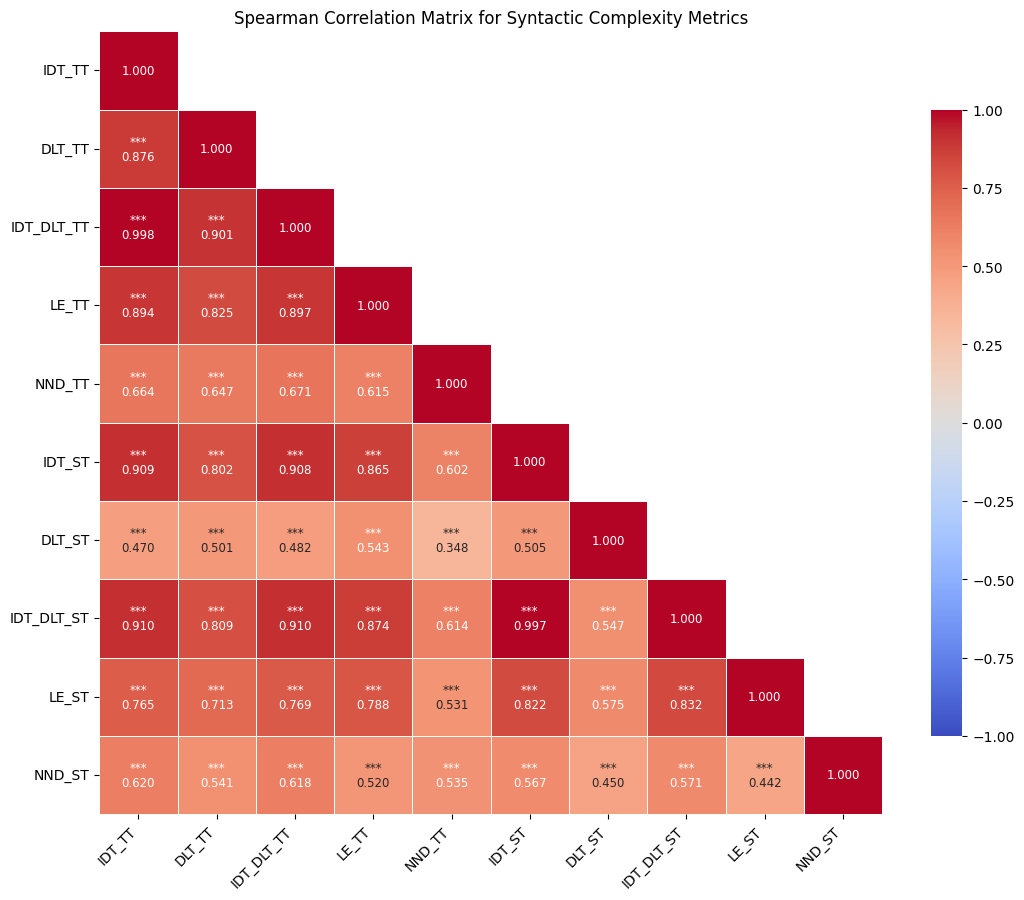

Significance levels: * p ≤ 0.05; ** p ≤ 0.01; *** p ≤ 0.001   (sum aggregation, n = 417 segments)


In [24]:
# --- Spearman correlation matrix (lower triangle, with significance) ---

order = ["IDT", "DLT", "IDT_DLT", "LE", "NND"]
cols = [m + "_TT" for m in order] + [m + "_ST" for m in order]
data = df[cols].dropna()
n = len(cols)

rho = np.ones((n, n))
pval = np.zeros((n, n))
for i in range(n):
    for j in range(i):
        r, p = stats.spearmanr(data[cols[i]], data[cols[j]])
        rho[i, j] = rho[j, i] = r
        pval[i, j] = pval[j, i] = p

def stars(p):
    return "***" if p <= 0.001 else "**" if p <= 0.01 else "*" if p <= 0.05 else ""

annot = np.empty((n, n), dtype=object)
for i in range(n):
    for j in range(n):
        annot[i, j] = "1.000" if i == j else f"{stars(pval[i, j])}\n{rho[i, j]:.3f}"

mask = np.triu(np.ones((n, n), dtype=bool), k=1)   # show lower triangle + diagonal
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(pd.DataFrame(rho, index=cols, columns=cols), mask=mask,
            annot=pd.DataFrame(annot, index=cols, columns=cols), fmt="",
            cmap="coolwarm", vmin=-1, vmax=1, square=True,
            linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.8}, annot_kws={"fontsize": 8.5}, ax=ax)
ax.set_title("Spearman Correlation Matrix for Syntactic Complexity Metrics")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
print(f"Significance levels: * p ≤ 0.05; ** p ≤ 0.01; *** p ≤ 0.001   "
      f"(sum aggregation, n = {len(data)} segments)")

### One-figure summary: which complexity metrics relate to quality?

The two tables above hold the exact values; this figure shows the whole result pattern at a glance. Each row is a complexity metric; markers give its Spearman ρ with BLEU (cum-4) and with COMET-QE, with whiskers showing the **95% confidence interval** of ρ (Fisher z with the Bonett–Wright standard error). **Filled markers**: the interval excludes zero; **open markers**: it does not. Notice how the interval widths tell the power story directly — source-side metrics are correlated at the segment level (n ≈ 41 → wide intervals), BCR metrics at the row level (n ≈ 417 → narrow intervals). Metrics left of the zero line associate with *lower* quality.

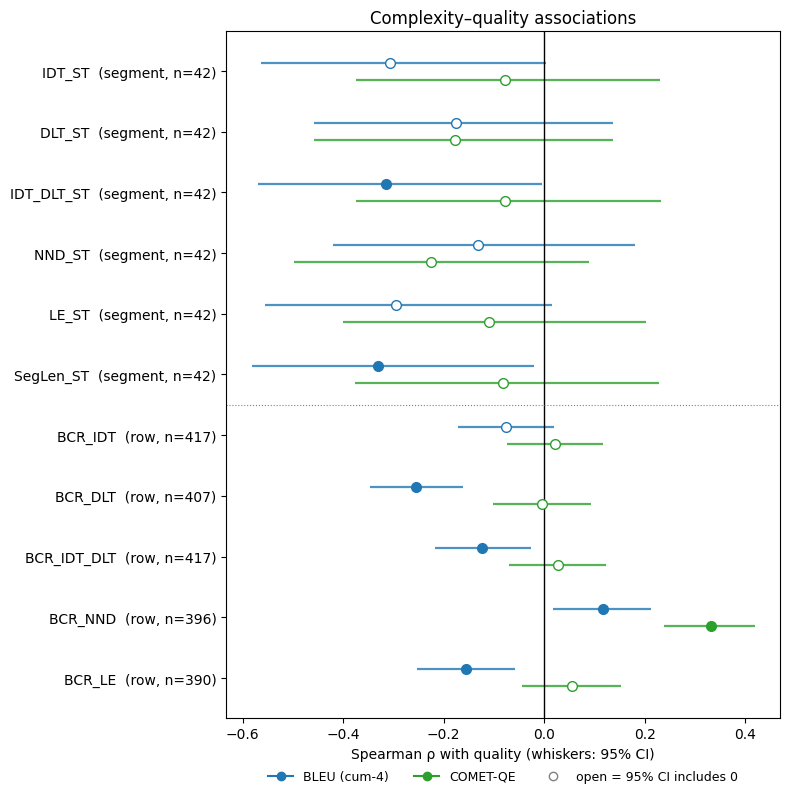

In [25]:
# --- Forest plot: Spearman rho of every complexity metric vs both quality scores ---

def spearman_ci(rho, n, conf=1.96):
    # Fisher z CI with the Bonett-Wright (2000) SE for Spearman's rho
    se = np.sqrt((1 + rho ** 2 / 2) / (n - 3))
    z = np.arctanh(rho)
    return np.tanh(z - conf * se), np.tanh(z + conf * se)

specs = ([(c, seg_level, "segment") for c in ST_COLS + ["SegLen_ST"]]
         + [(c, df, "row") for c in BCR_COLS])

labels, ys = [], []
fig, ax = plt.subplots(figsize=(8, 0.55 * len(specs) + 2))
for y, (c, d, level) in enumerate(specs):
    for q, color, dx in (("cum-4", "tab:blue", -0.14), ("COMET_QE", "tab:green", 0.14)):
        sub = d[[c, q]].dropna()
        rho, _ = stats.spearmanr(sub[c], sub[q])
        lo, hi = spearman_ci(rho, len(sub))
        sig = lo > 0 or hi < 0                 # CI excludes zero
        ax.plot([lo, hi], [y + dx, y + dx], color=color, lw=1.6, alpha=0.8,
                solid_capstyle="butt")
        ax.plot(rho, y + dx, "o", color=color, markersize=7,
                markerfacecolor=color if sig else "white", zorder=3)
    labels.append(f"{c}  ({level}, n={len(d[[c]].dropna())})")
    ys.append(y)

ax.axvline(0, color="black", lw=1)
ax.axhline(len(ST_COLS) + 0.5, color="grey", lw=0.8, ls=":")  # ST | BCR divider
ax.set_yticks(ys)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Spearman ρ with quality (whiskers: 95% CI)")
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([], [], marker="o", color="tab:blue", ls="-", label="BLEU (cum-4)"),
    Line2D([], [], marker="o", color="tab:green", ls="-", label="COMET-QE"),
    Line2D([], [], marker="o", color="grey", markerfacecolor="white", ls="",
           label="open = 95% CI includes 0")],
    loc="upper center", bbox_to_anchor=(0.5, -0.06), ncol=3,
    frameon=False, fontsize=9)
ax.set_title("Complexity–quality associations")
plt.tight_layout()
plt.show()

### Interpreting what you see

- **BLEU** (multi-reference, T-pool): how close each post-edited segment is to the space of independent human translations of the same source.
- **COMET-QE**: model-estimated adequacy/fluency of each (source, post-edited target) pair, judged without any reference.
- **The BLEU–COMET correlation** tells you how well proximity-to-human-translations tracks estimated quality (segment-level ρ ≈ 0.3–0.5 is typical).
- **Complexity correlations**: negative ST-metric correlations mean harder source syntax → lower post-editing quality; BCR relates each post-editor's syntactic restructuring to the quality of the result.

💡 In Colab, download `ruc17_bleu_comet.csv` from the file browser (📁 icon on the left) before the runtime disconnects.

---

## 🏋️ Practice Exercises

### Exercise 1 — Evaluate the from-scratch translations

This lesson scored only the post-editing (P) sessions. Re-run the quality evaluation for the **from-scratch translations (T sessions)** instead.

**How:** in the Step 2 BLEU cell, change the hypothesis filter to `segments["Task"] == "T"` — everything downstream (the COMET pairs in Step 3 reuse `hypotheses`) follows automatically.

**Look closely at one line before you run:** the BLEU loop contains `if ref_sess == sess: continue`. For P hypotheses it never fires. What does it do once your hypotheses come from the *same* sessions as the reference pool — and what would go wrong without it?

**Interpret:**
- Which task scores higher BLEU against the human-translation pool? (Expect P.) Before you conclude that post-edited text is *better*, recall that all P sessions share the same MT backbone: does "closer to the pool" mean higher quality, or convergence toward the center of translation space?
- T hypotheses get one fewer reference than P hypotheses (why?). How would you make the comparison fair?
- Does COMET-QE — which needs no references — show the same P–T gap? What does agreement or disagreement between the two metrics tell you?

### Exercise 2 — Process meets product: behavioral measures × quality

The merged table `df` carries the SG behavioral measures for every segment — `Dur`, `Ins`, `Del`, `TrtS`, `TrtT`, `Nedit` — but this lesson never analyzed them. Correlate them with the quality metrics.

**How:** these measures vary per row (like BCR), so adapt the BCR correlation cell in Step 6: swap `BCR_COLS` for a list of behavioral columns. `Nedit` is NaN for the few split rows — `dropna()` handles it. For a visual, add the behavioral rows to the forest plot's `specs` list.

**Interpret:**
- Is more editing effort associated with higher or lower quality scores? Is the direction the same for BLEU and for COMET-QE?
- Suppose `Dur` correlates negatively with BLEU. Two very different stories fit that number: *effort produces worse text*, or *difficult segments demand effort AND legitimately diverge from the references*. Which do you believe, and how could you tell them apart? (Hint: what happens to the correlation if you control for `SegLen_ST`, or compare segments within the same source text?)
- In translation process research terms: what would it mean to find that process measures predict COMET but not BLEU, or vice versa?

### 🌶️ Stretch goals

- Set `COMET_MODEL = "Unbabel/wmt22-cometkiwi-da"` (Step 4) and check which findings survive the stronger QE model.
- Set `AGGREGATION = "mean"` in Step 6 and see which complexity–quality correlations depend on the sum aggregation's length component.

---

## 📚 References and Resources

### Further Resources

* Parallel-text preparation (`prep_parallel_texts`): [tprdb-utilities on PyPI](https://pypi.org/project/tprdb-utilities/)
* Syntactic complexity toolkit (Step 6 metrics): [Critt-Kent/Syntactic-complexity](https://github.com/Critt-Kent/Syntactic-complexity)
* TPR-DB data tables: [Data Tables (3.0) — TPR-DB Documentation](https://critt-kent.github.io/TPR-DB-documentation/analyze/types/)
* Product features (SG/ST/TT measures used here): [Product Features — TPR-DB Documentation](https://critt-kent.github.io/TPR-DB-documentation/analyze/product/)

### Syntactic complexity & post-editing

- Zou, L., Carl, M., & Feng, J. (2025). How dependency-based syntactic complexity shapes post-editing of LLM-generated translations: Global and diagnostic evidence. *Translation, Cognition & Behavior, 8*(2), 217–248.
- Zou, L., Carl, M., & Feng, J. (2025). Cognitive processes of post-editing generative AI: Examining student translators' interactions with ChatGPT outputs. In *Translation Studies in the Age of Artificial Intelligence* (pp. 190–209). Routledge.
- Zou, L., Carl, M., Momtaz, S., & Mirzapour, M. (2024). Impact of syntactic complexity on the processes and performance of large language models-leveraged post-editing. In *Proceedings of the 16th Conference of the Association for Machine Translation in the Americas (Vol. 2)* (pp. 259–260).
- Zou, L. (2024). *Cognitive processes in human-ChatGPT interaction during machine translation post-editing* [PhD thesis, Kent State University].
- Zou, L., Carl, M., Mirzapour, M., Jacquenet, H., & Vieira, L. N. (2021). AI-based syntactic complexity metrics and sight interpreting performance. In *International Conference on Intelligent Human Computer Interaction* (pp. 534–547). Springer.

### Method references

- Papineni, K., Roukos, S., Ward, T., & Zhu, W.-J. (2002). BLEU: A method for automatic evaluation of machine translation. In *Proceedings of ACL 2002* (pp. 311–318).
- Rei, R., Stewart, C., Farinha, A. C., & Lavie, A. (2020). COMET: A neural framework for MT evaluation. In *Proceedings of EMNLP 2020* (pp. 2685–2702).
- Rei, R., et al. (2022). CometKiwi: IST-Unbabel 2022 submission for the quality estimation shared task. In *Proceedings of WMT 2022* (pp. 634–645).
- Gibson, E. (1998). Linguistic complexity: Locality of syntactic dependencies. *Cognition, 68*(1), 1–76.
- Gibson, E. (2000). The dependency locality theory: A distance-based theory of linguistic complexity. In *Image, Language, Brain* (pp. 95–126).
- De Marneffe, M.-C., Manning, C. D., Nivre, J., & Zeman, D. (2021). Universal Dependencies. *Computational Linguistics, 47*(2), 255–308.

<details>
<summary><b>BibTeX</b> (click to expand)</summary>

```bibtex
@article{zou2025dependency,
  title={How dependency-based syntactic complexity shapes post-editing of LLM-generated translations: Global and diagnostic evidence},
  author={Zou, Longhui and Carl, Michael and Feng, Jia},
  journal={Translation, Cognition \& Behavior},
  volume={8}, number={2}, pages={217--248}, year={2025},
  publisher={John Benjamins Publishing Company Amsterdam/Philadelphia}
}
@incollection{zou2025cognitive,
  title={Cognitive Processes of Post-editing Generative AI: Examining Student Translators' Interactions with ChatGPT Outputs},
  author={Zou, Longhui and Carl, Michael and Feng, Jia},
  booktitle={Translation Studies in the Age of Artificial Intelligence},
  pages={190--209}, year={2025}, publisher={Routledge}
}
@inproceedings{zou2024impact,
  title={Impact of syntactic complexity on the processes and performance of large language models-leveraged post-editing},
  author={Zou, Longhui and Carl, Michael and Momtaz, Shaghayegh and Mirzapour, Mehdi},
  booktitle={Proceedings of the 16th Conference of the Association for Machine Translation in the Americas (Volume 2: Presentations)},
  pages={259--260}, year={2024}
}
@phdthesis{zou2024cognitive,
  title={Cognitive Processes in Human-ChatGPT Interaction during Machine Translation Post-editing},
  author={Zou, Longhui},
  year={2024}, school={Kent State University}
}
@inproceedings{zou2021ai,
  title={AI-based syntactic complexity metrics and sight interpreting performance},
  author={Zou, Longhui and Carl, Michael and Mirzapour, Mehdi and Jacquenet, H{\'e}l{\`e}ne and Vieira, Lucas Nunes},
  booktitle={International Conference on Intelligent Human Computer Interaction},
  pages={534--547}, year={2021}, organization={Springer}
}
```
</details>